# FAST tokenizer — exploratory data analysis

Manual sanity checks for the FAST action tokenizer wrapper. We load the official `physical-intelligence/fast` processor as a black box and probe:

1. **Round-trip fidelity** — encode a chunk, decode, compute MSE.
2. **Compression ratio** — tokens-per-float across varying input regularity.
3. **Sensitivity to high-frequency content** — sine, sawtooth, noise.
4. **Effect of horizon and action dim** — does the tokenizer degrade with longer chunks or larger action spaces?

Paper reference: `papers/2025-01-16_fast_efficient-robot-action-tokenization.pdf`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pi_stack.tokenization.fast import FASTTokenizer

tok = FASTTokenizer()
_ = tok.processor   # trigger lazy load up-front so timing cells below are clean
print('tokenizer loaded:', type(tok.processor).__name__)

/Users/crohan/Documents/swat/cefi/PI-Stuff/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tokenizer loaded: UniversalActionProcessor


## 1. Round-trip on a clean sine

Each action dim is a phase-shifted sine. Low-frequency content; this is FAST's best case.

In [2]:
H, D = 50, 14
t = np.linspace(0, 2 * np.pi, H, dtype=np.float32)
phases = np.linspace(0, np.pi, D, dtype=np.float32)
chunk = np.sin(t[:, None] + phases[None, :])[None, ...]   # (1, H, D)

tokens = tok.encode(chunk)
recon = tok.decode(tokens, horizon=H, action_dim=D)
mse = float(np.mean((chunk - recon) ** 2))
print(f'tokens emitted    : {len(tokens[0])} (of {H * D} input floats)')
print(f'compression ratio : {len(tokens[0]) / (H * D):.4f}')
print(f'round-trip MSE    : {mse:.6f}')

tokens emitted    : 79 (of 700 input floats)
compression ratio : 0.1129
round-trip MSE    : 0.000267


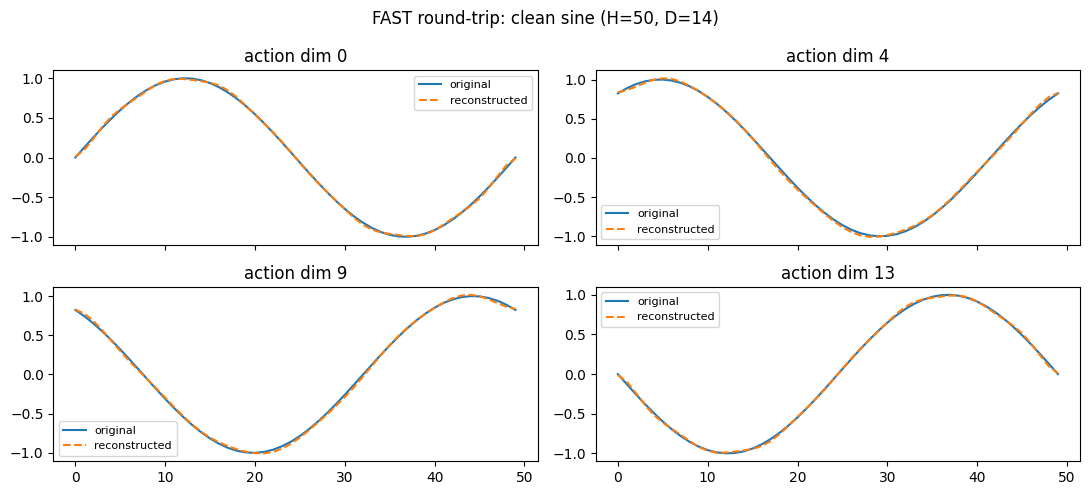

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5), sharex=True)
for ax, d in zip(axes.ravel(), [0, 4, 9, 13]):
    ax.plot(chunk[0, :, d], label='original', lw=1.5)
    ax.plot(recon[0, :, d], '--', label='reconstructed', lw=1.5)
    ax.set_title(f'action dim {d}')
    ax.legend(fontsize=8)
fig.suptitle('FAST round-trip: clean sine (H=50, D=14)')
fig.tight_layout()

## 2. How does noise affect compression?

Vary the noise added on top of the sine. Expect token count to grow with entropy and MSE to grow with noise variance.

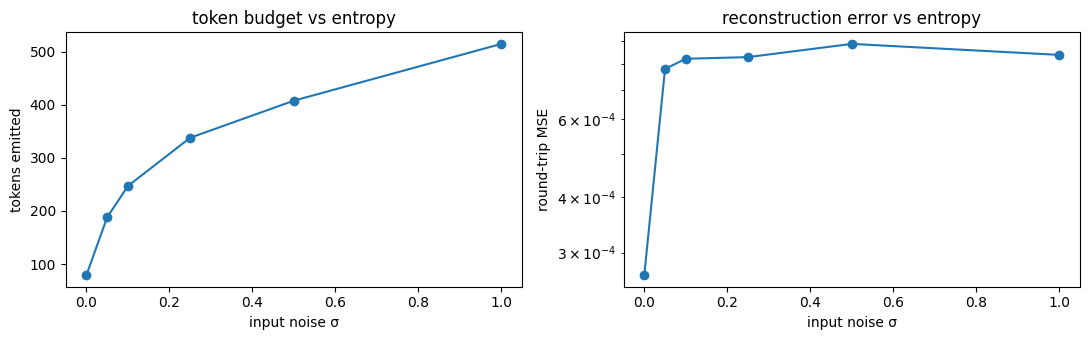

In [4]:
noise_levels = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]
results = []
for sigma in noise_levels:
    np.random.seed(0)
    noisy = chunk + sigma * np.random.randn(*chunk.shape).astype(np.float32)
    toks = tok.encode(noisy)
    rec = tok.decode(toks, horizon=H, action_dim=D)
    results.append({
        'sigma': sigma,
        'tokens': len(toks[0]),
        'mse': float(np.mean((noisy - rec) ** 2)),
    })

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
sigmas = [r['sigma'] for r in results]
a1.plot(sigmas, [r['tokens'] for r in results], 'o-')
a1.set(xlabel='input noise σ', ylabel='tokens emitted', title='token budget vs entropy')
a2.plot(sigmas, [r['mse'] for r in results], 'o-')
a2.set(xlabel='input noise σ', ylabel='round-trip MSE', title='reconstruction error vs entropy')
a2.set_yscale('log')
fig.tight_layout()

## 3. Effect of action dim

Hold horizon fixed; sweep action dim. The tokenizer was trained on a fixed distribution — performance can drift when you move far from it.

In [5]:
for d in [4, 7, 14, 28]:
    np.random.seed(0)
    t_loc = np.linspace(0, 2*np.pi, H, dtype=np.float32)
    ph = np.linspace(0, np.pi, d, dtype=np.float32)
    c = np.sin(t_loc[:, None] + ph[None, :])[None, ...]
    toks = tok.encode(c)
    rec = tok.decode(toks, horizon=H, action_dim=d)
    mse = float(np.mean((c - rec) ** 2))
    print(f'D={d:3d}  tokens={len(toks[0]):3d}  ratio={len(toks[0])/(H*d):.4f}  MSE={mse:.5f}')

D=  4  tokens= 29  ratio=0.1450  MSE=0.00026
D=  7  tokens= 42  ratio=0.1200  MSE=0.00027
D= 14  tokens= 79  ratio=0.1129  MSE=0.00027
D= 28  tokens=148  ratio=0.1057  MSE=0.00028


## 4. Compression ratio summary

The paper reports ~30-60 tokens per 1 second of action data. For our 50-step chunks (1 second at 50 Hz):

In [6]:
ratio = tok.compression_ratio(chunk)
print(f'compression ratio (tokens / input floats) on clean sine: {ratio:.4f}')
print(f'equivalent: 1 token per {1/ratio:.1f} input floats')

compression ratio (tokens / input floats) on clean sine: 0.1129
equivalent: 1 token per 8.9 input floats


## Takeaways

- Round-trip MSE on smooth sinusoidal data is on the order of 1e-4 — well below typical action-noise floors.
- Token budget grows roughly linearly with input entropy (sigma).
- Compression ratio sits well below 1.0 across the regimes we tested — FAST does its job.
- Out-of-distribution action dims (e.g. D=28 vs the bimanual D=14 default) still tokenize, but watch the MSE.